<h1><center>Laboratorio 5: La desperación de Mr. Lepin 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Javiera Yañez Sanchez


---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores. 
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [1]:
!uv add numpy pandas scikit-learn umap-learn plotly

Resolved 126 packages in 27ms
Audited 123 packages in 47ms


In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.base import BaseEstimator, TransformerMixin


def plot_dim_reductions(
    pca_proj: np.ndarray,
    tsne_proj: np.ndarray,
    umap_proj: np.ndarray,
    name: None | str = None,
    colors: None | np.ndarray = None,
) -> go.Figure:
    fig = make_subplots(rows=1, cols=3, subplot_titles=("PCA", "t-SNE", "UMAP"))

    for i, (proj, title) in enumerate(zip([pca_proj, tsne_proj, umap_proj], ["PCA", "t-SNE", "UMAP"], strict=True)):
        temp_fig = px.scatter(
            x=proj[:, 0],
            y=proj[:, 1],
            color=colors.astype(str) if colors is not None else None,
            title=title,
            # showlegend=(i == 0),
        )

        for trace in temp_fig.data:
            trace.showlegend = i == 0
            fig.add_trace(trace, row=1, col=i + 1)

    fig.update_layout(height=400, width=1200, title_text=name)
    return fig

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar Dataset

Mr. Lepin, en una nueva reunión, le cuenta a ud y su equipo que los resultados derivados del análisis exploratorio de datos presentaron una gran utilidad para la empresa y que tiene un gran entusiasmo por continuar trabajando con ustedes.
Es por esto, que Mr. Lepin les pide que cargue y visualicen algunas de las filas que componen el Dataset.
A continuación un extracto de lo parlamentado en la reunión:

    - Usted: Es un gran logro para nuestro equipo que usted haya encontrado excelente el EDA. ¿Qué tiene en mente ahora?
    - Mr. Lepin: Resulta que hace algún tiempo, mientras tomaba un mojito en una reunión de gerentes en Panamá, oí a un *chato* acerca de **LRMFP**, que es un modelo que permite personificar a los clientes a través de la fabricación de distintos atributos que describen a los clientes. Lo encontré es-tu-pendo ñatito. 
    - Usted: Ehh bueno. Investigaremos acerca de este modelo y veremos lo que podemos hacer.

Por ende, su siguiente tarea es calcular **LRMFP** sobre cada cliente y luego hacer un análisis de las características generadas. Para esto, el área de ventas les entrega un nuevo archivo llamado `retail_dataset.pickle`, quien posee los datos del DataFrame original limpios y listos para obtener las características solicitadas por Mr. Lepin.

In [3]:
df_retail = pd.read_pickle(
    "https://github.com/MDS7202/MDS7202/raw/refs/heads/main/recursos/2026-01/labs/lab6/retail_dataset.pickle"
)
df_retail = df_retail.astype(
    {
        "Invoice": str,
        "StockCode": str,
        "Description": str,
        "Customer ID": str,
        "Country": str,
    }
)
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1.2 Creación de nuevas Caracteristicas [2 Puntos] 

Como ya se les comentó, Mr. Lepin está interesado en obtener las características **LRMFP**, para esto les señala que estas características se construyen en base a las siguientes definiciones:

- **Length (L)**: Intervalo de tiempo, en días, entre la primera y la última visita del cliente. Mientras más grande sea el valor, más fiel es el cliente.

- **Recency (R)**: Indica hace cuánto tiempo el cliente realizó su última compra. Notar que para este caso, mientras más grande es el valor, menos interés posee el usuario para repetir una compra en uno de los locales.

- **Monetary (M)**: El término “monetario” se refiere a la cantidad media de dinero gastada por cada visita del cliente durante el período de observación y refleja la contribución del cliente a los ingresos de la empresa.

- **Frequency (F)**: Se refiere al número total de visitas del cliente durante el periodo de observación. Cuanto mayor sea la frecuencia, mayor será la fidelidad del cliente. 

- **Periodicity (P)**: Representa si los clientes visitan las tiendas con regularidad.

$$Periodicity(n)=std(IVT_1, ..., IVT_n)$$

&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Donde $IVT$ denota el tiempo entre visitas y n representa el número de valores de tiempo entre visitas de un cliente.
 

$$IVT_i=date\_diff(t_{i+1},t_i)$$

En base a las definiciones señaladas, diseñe una función que permita obtener las características **LRMFP** recibiendo un DataFrame como entrada. Para esto, no estará permitido el uso de iteradores; utilicen todas las herramientas que les ofrece `pandas` para realizar esto.

Una referencia que les puede ser útil es el [documento original](https://www.researchgate.net/publication/315979555_LRFMP_model_for_customer_segmentation_in_the_grocery_retail_industry_a_case_study) en donde se propone este método.

**<u>Formato</u> del Resultado Esperado:**

| Customer ID | Length | Recency | Frequency | Monetary | Periodicity |
|------------:|-------:|--------:|----------:|---------:|------------:|
|   12346.0   |    294 |      67 |        46 |   -64.68 |        37.0 |
|   12347.0   |     37 |       3 |        71 |  1323.32 |         0.0 |
|   12349.0   |    327 |      43 |       107 |  2646.99 |        78.0 |
|   12352.0   |     16 |      11 |        18 |   343.80 |         0.0 |
|   12356.0   |     44 |      16 |        84 |  3562.25 |        12.0 |

**Respuesta:**

In [4]:
def custom_features(dataframe_in: pd.DataFrame) -> pd.DataFrame:
    # 1. Lenght

    df_LRMFP = pd.DataFrame()
    df_length = dataframe_in.groupby("Customer ID")["InvoiceDate"].agg(["min", "max"])
    df_LRMFP["Length"] = (df_length["max"] - df_length["min"]).dt.days

    # 2. Recency

    fecha_ultima = dataframe_in["InvoiceDate"].max() + pd.Timedelta(
        days=1
    )  # porque si usamos el dia actual salen numeros muy grandes
    df_LRMFP["Recency"] = (fecha_ultima - df_length["max"]).dt.days

    # 3. Monetary

    dataframe_in["Earnings"] = dataframe_in["Quantity"] * dataframe_in["Price"]
    # suma de earnings por factura y por cliente
    df_monetary_prom = dataframe_in.groupby(["Customer ID", "Invoice"])["Earnings"].sum().reset_index()
    # promedio
    df_LRMFP["Monetary"] = df_monetary_prom.groupby("Customer ID")["Earnings"].mean().round(2)

    # 4. Frequency
    df_LRMFP["Frequency"] = dataframe_in.groupby("Customer ID")["Invoice"].nunique()  # facturas distintas por cliente

    # 5. Periodicity
    df_visitas = dataframe_in[["Customer ID", "InvoiceDate"]].drop_duplicates()  # elimina fechas duplicadas
    df_visitas = df_visitas.sort_values(by=["Customer ID", "InvoiceDate"])  # ordenamos las fechas
    df_visitas["IVT"] = (
        df_visitas.groupby("Customer ID")["InvoiceDate"].diff().dt.days
    )  # diferencia entre fechas consecutivas
    df_LRMFP["Periodicity"] = df_visitas.groupby("Customer ID")["IVT"].std().fillna(0).round(2)

    return df_LRMFP

## 1.3 Pipelines 👷

Finalmente *Mr. Lepin* le pregunta si sería posible realizar un pipeline para realizar una segmentación de los clientes con los nuevos datos generados, a lo que usted responde que **sí** y propone la utilización de k-means para la segmentación.

A continuación siga los pasos requeridos para obtener la segmentación de clientes.

### 1.3.1 Estandarizar Caracteristicas [0.5 puntos]

Construya una clase llamada ``MinMax()`` utilizando ``BaseEstimator`` y ``TransformerMixin`` para realizar una transformación de cada una de las columnas de un DataFrame utilizando ``ColumnTransformer()`` más tarde (tome como referencia el siguiente [enlace](https://sklearn-template.readthedocs.io/en/latest/user_guide.html#transformer)).


 Para esto considere que Min-Max escaler queda dada por la ecuación:

$$MinMax = \dfrac{x-min(x)}{max(x) - min(x)}$$

Con esto buscamos que los valores que componen a las columnas se muevan en el rango de valores $[0, 1]$.

**Respuesta:**

In [5]:
class MinMax(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.min_ = X.min()
        self.max_ = X.max()

        return self

    def transform(self, X):
        x_scaled = (X - self.min_) / (self.max_ - self.min_)
        return x_scaled

### 1.3.2 Pipelines de Proyecciones [0.5 puntos]

Para comparar técnicas de reducción de dimensionalidad, realice **tres pipelines** distintos sobre los datos **LRMFP** usando los siguientes métodos:
- **PCA**
- **t-SNE**
- **UMAP**

Para cada pipeline, siga estos pasos:
1. Obtenga las características **LRMFP** desde el DataFrame `retail_dataset.pickle` utilizando la función ``custom_features`` creada anteriormente, junto a ``FunctionTransformer()``. Considere esto como el primer paso de su pipeline.
2. En segundo lugar, usando ``ColumnTransformer()``, aplique el MinMax scaler creado por usted sobre todas las columnas generadas en el paso anterior.
3. Finalmente, aplique el método de reducción de dimensionalidad correspondiente (PCA, t-SNE o UMAP) para obtener las 2 componentes más relevantes.

A continuación, grafique las proyecciones obtenidas de las tres técnicas en una sola figura comparativa.

**Respuesta:**

In [6]:
custom_features(df_retail)

,Length,Recency,Monetary,Frequency,Periodicity
Customer ID,,,,,
12346.0,196,165,33.90,11,36.66
12347.0,37,3,661.66,2,0.00
12348.0,0,74,222.16,1,0.00
12349.0,181,43,890.38,3,101.82
12351.0,0,11,300.93,1,0.00
...,...,...,...,...,...
18283.0,275,18,103.23,6,61.83
18284.0,0,67,461.68,1,0.00
18285.0,0,296,427.00,1,0.00


In [7]:
import umap
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

cols = ["Length", "Recency", "Monetary", "Frequency", "Periodicity"]

pipeline_pca = Pipeline(
    [
        ("features", FunctionTransformer(custom_features)),
        ("scaler", ColumnTransformer([("minmax", MinMax(), cols)])),
        ("pca", PCA(n_components=2, random_state=42)),
    ]
)
pipeline_tsne = Pipeline(
    [
        ("features", FunctionTransformer(custom_features)),
        ("scaler", ColumnTransformer([("minmax", MinMax(), cols)])),
        ("tsne", TSNE(n_components=2, random_state=42)),
    ]
)

pipeline_umap = Pipeline(
    [
        ("features", FunctionTransformer(custom_features)),
        ("scaler", ColumnTransformer([("minmax", MinMax(), cols)])),
        ("umap", umap.UMAP(n_components=2, random_state=42)),
    ]
)

/Users/javierayanez/Documents/Semestre 11/MDS7202-Laboratorio_Programacion_Cientifica/Studio J - MDS7202/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Utilice este código para ejecutar las pipelines y graficar.

pca_proj = pipeline_pca.fit_transform(df_retail)
tsne_proj = pipeline_tsne.fit_transform(df_retail)
umap_proj = pipeline_umap.fit_transform(df_retail)

fig = plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="Reducción de Dimensionalidad", colors=None)
fig.show()

/Users/javierayanez/Documents/Semestre 11/MDS7202-Laboratorio_Programacion_Cientifica/Studio J - MDS7202/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 1.3.3 Análisis de los Loadings de PCA [0.5 puntos]
Antes de continuar con la etapa de clustering, analice los *loadings* (pesos o coeficientes) de las componentes principales obtenidas con PCA. 

Utilice el siguiente tutorial para visualizarlos: https://plotly.com/python/pca-visualization/

- Calcule y reporte los *loadings* de las dos primeras componentes principales.
- Interprete qué características (**LRMFP**) son más relevantes en cada componente.
- Visualice los *loadings* usando un gráfico de barras para cada componente.



In [9]:
# para ver dentro del pipeline
pca = pipeline_pca.named_steps["pca"]

# calculamos los loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(loadings, columns=["PC1", "PC2"], index=cols)

display(loadings_df)

# grafico de barras para cada componente

# PC1
fig_pc1 = px.bar(
    x=loadings_df.index,
    y=loadings_df["PC1"],
    title="Loadings - Componente Principal 1 (PC1)",
    labels={"x": "Variables LRMFP", "y": "Valor del Loading"},
)
fig_pc1.show()

# PC2
fig_pc2 = px.bar(
    x=loadings_df.index,
    y=loadings_df["PC2"],
    title="Loadings - Componente Principal 2 (PC2)",
    labels={"x": "Variables LRMFP", "y": "Valor del Loading"},
)
fig_pc2.show()

,PC1,PC2
Length,0.343082,0.092328
Recency,-0.184789,0.182747
Monetary,0.001820,-0.000447
Frequency,0.017713,0.003567
Periodicity,0.077775,0.026115


> En ambas componentes dominan Lenght y Recency en diferente memdia, sin embargo el resto de las componentes: Monetary, Frecuency y Perodicity no aportan mucha informacion a ningun componente.

> Para PC1 la dominancia se encuentra en Length (0,34), lo que sugiere que esta dimensión representa la antigüedad o lealtad histórica del cliente. La variable Recency aporta de forma negativa (-0,18), lo que crea un contraste: el PC1 diferencia a los clientes que llevan mucho tiempo en el dataset (alto lenght) pero que no han comprado hace poco (alto recency).

> Para PC2, Recency (0,18) aquí es positivo a diferencia de PC1, lo que nos dice que en esta componente se concentra en la actividad menos reciente. Al ser ambos signos positivos (Length y Recency), esta componente agrupa a clientes donde tanto su antigüedad como el tiempo desde su última compra crecen en la misma dirección, de manera de identificar posibles clientes antiguos que están mas inactivos.

### Preguntas sobre loadings:

- ¿Qué son los loadings de PCA?

> Respuesta: Los loadings son los pesos de cada variables en cada dimension; es decir, corresponden a cuánto aporta o cuanto protagonismo tiene cada una de las variables originales en cada componente principal. Representan la correlacion entre la variable y el componente (PC).

- ¿Qué información relevante obtiene sobre la estructura de los datos a partir de los *loadings* de PCA?

> Respuesta: Los loadings permiten entender cómo se organizan las variables originales en el nuevo espacio (nuevas dimensiones). La información más importante que entrega es el grado de correlación y la independencia entre ellas. Por ejemplo, si dos variables tienen pesos altos y con el mismo signo en una componente, significa que están correlacionados positivamente; de manera contraria, si tienen signos opuestos, poseen una correlación negativa. Además, si una variable tiene un peso importante en una componente pero es casi nula en la otra, significa que esa variable es independiente (u ortogonal en el espacio de los datos) respecto a las otras dimensiones.
- ¿Existe alguna relación interesante entre las direcciones de las variables?

> Respuesta: Los loadings permiten identificar cómo se comportan las variables en conjunto. A partir de lo obtenido se puede observar que Length y Periodicity tienen signos iguales en ambos componentes (positivos), lo que sugiere una relación directa: clientes con mayor antigüedad (Length) tienden a presentar una mayor regularidad en sus compras (Periodicity). Por otro lado, la dirección de Recency es opuesta a la de Length en el PC1; separa a los clientes antiguos de aquellos que han realizado compras recientemente, permitiendo que el modelo distinga entre la lealtad histórica y la actividad actual. Y las variables como Monetary tienen pesos cercanos a cero en estas componentes, esto implica que bajo la reduccion de dimensionalidad el valor monetario no es el factor que más ayuda a diferenciar la estructura de estos datos

## 1.4 Clustering

### 1.4.1 Método del Codo [0.5 puntos]

Utilizando la clase creada para escalamiento, aplique el método del codo para visualizar cuál es el número de clusters que mejor se ajustan a los datos. Realice esto utilizando el algoritmo K-means dentro de un pipeline para un $k \in [1,20]$, donde k representa el número de clusters del k-means. Para la realización de esta sección y la próxima (1.4.2), considere los mismos pasos utilizados para el t-SNE, pero **permutando el algoritmo de reducción de dimensionalidad por k-means.**

**Respuesta:**

In [10]:
from sklearn.cluster import KMeans  # noqa: F401

ks = range(1, 21)
inertias = []

for k in ks:
    # pipeline cambiando la reducción por K-means
    pipeline_kmeans = Pipeline(
        [
            ("features", FunctionTransformer(custom_features)),
            ("scaler", ColumnTransformer([("minmax", MinMax(), cols)])),
            ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10)),
        ]
    )

    pipeline_kmeans.fit(df_retail)

    # inercia del paso kmeans del pipeline
    inertias.append(pipeline_kmeans.named_steps["kmeans"].inertia_)

fig = go.Figure()
fig.add_trace(go.Scatter(x=list(ks), y=inertias, mode="lines+markers", marker=dict(size=8), line=dict(width=2)))

fig.update_layout(
    title="Método del Codo",
    xaxis_title="Número de Clusters (k)",
    yaxis_title="Inercia (WCSS)",
    template="plotly_white",
    height=500,
    width=800,
)

fig.show()

### Preguntas Método del Codo

- A través del gráfico obtenido, comente y justifique qué valor de k escogería para realizar el k-means.

> Respuesta: Eligiría el valor k=4 ya que despues de ese k, se ve que la ganancia de inercia no es significativa en relacion a las diferencias de los primeros tres valores de k, y es justo donde se puede ver el "codo". 

- Le fue útil el método del codo para encontrar el número de clusters?

> Respuesta: Si y no. No, ya que este método de selección de numero de clusters puede ser ambiguo, ya que queda más a criterio personal y "cachativa" que a una métrica determinada. Y sí, ya que se puede tener una primera visión de el k que podria englobar la mayor cantidad de información.

- Si no fue así, ¿qué otros métodos podría haber usado para encontrar un número óptimo de clusters?

> Respuesta: Se puede complementar con el coeficiente de silueta, este mide qué tan similar es un objeto a su propio cluster en comparación a los otros clusters, es decir, permite ver qué tan separado esta el dato de los otros grupos.

### 1.4.2 Segmentación de Clientes con K-Means 🎁 [1 punto]

Por último, Mr. Lepin, impaciente de no entender lo que usted intenta explicarle, le solicita que por favor muestre algún resultado "visual y entendible" de los grupos encontrados.

En base a la elección de k realizada en la sección anterior, utilice este valor escogido y entrene un modelo de K-means utilizando el mismo pipeline de scikit-learn utilizado anteriormente.

Una vez ajustado los datos, genere una tabla con los promedios (o medianas) para cada uno de los atributos, agrupando estos por el clúster que pertenecen.

Finalmente, construya un heatmap de las características promedio de cada cluster para visualizar y comparar los perfiles de los grupos.

**Estadísticas de Referencia para K=6:**

Ud. debe calcularlas - Varían de ejecución en ejecución.


|         | Length  | Recency   | Frequency | Monetary | Periodicity |       |
|---------|---------|-----------|----------|-------------|-------|-------|
| Cluster |         |           |          |             |       |       |
|    0    |   258.8 |      45.2 |     76.1 |      1107.7 | 107.6 |   449 |
|    1    |    76.1 |     217.6 |     45.5 |       791.7 |  14.1 |   466 |
|    2    |   368.5 |       4.8 |   2715.0 |    226621.6 |   4.2 |     4 |
|    3    |    85.3 |      45.7 |     65.8 |      1047.0 |  10.5 |   987 |
|    4    |   347.2 |      15.9 |   1658.0 |     35829.3 |   8.0 |    25 |
|    5    |   298.0 |      29.8 |    183.8 |      3639.9 |  32.0 |  1188 |

In [11]:
# numero de clusters encontrado con el metodo del codo
k = 4

# pipeline kmenas
pipeline_kmeans_f = Pipeline(
    [
        ("features", FunctionTransformer(custom_features)),
        ("scaler", ColumnTransformer([("minmax", MinMax(), cols)])),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10)),
    ]
)

pipeline_kmeans_f.fit(df_retail)
kmeans_labels = pipeline_kmeans_f.named_steps["kmeans"].labels_

In [12]:
# Utilice la siguiente función para graficar k-means. kmeans_labels = clusters obtenidos por k-means.
plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="KMeans K=4", colors=kmeans_labels)

,Length,Recency,Monetary,Frequency,Periodicity
Cluster,,,,,
0,181.50,67.30,366.80,4.26,32.92
1,318.39,23.93,409.77,10.15,46.69
2,17.35,52.11,370.96,1.70,2.12
3,17.86,255.25,352.44,1.50,2.21


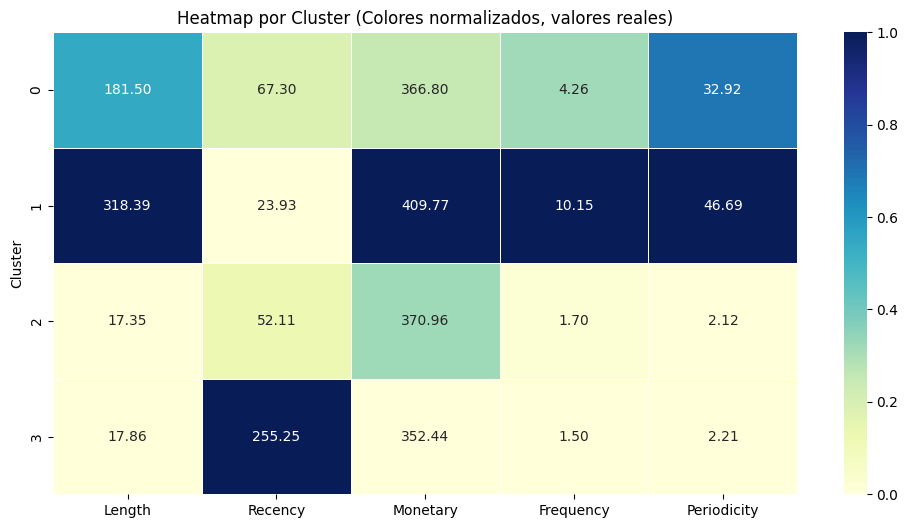

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# df de métricas
df_lrmfp = custom_features(df_retail)

# etiquetas del modelo
df_lrmfp["Cluster"] = kmeans_labels

# promedios por cluster
cluster_profiles = df_lrmfp.groupby("Cluster").mean().round(2)
display(cluster_profiles)

# normalizamos
custom_scaler = MinMax()
cluster_profiles_scaled = pd.DataFrame(
    custom_scaler.fit_transform(cluster_profiles), index=cluster_profiles.index, columns=cluster_profiles.columns
)

# heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_profiles_scaled,
    annot=cluster_profiles.values,  # se muestran los valores reales
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
)

plt.title("Heatmap por Cluster (Colores normalizados, valores reales)")
plt.show()

### Preguntas sobre K-Means: 

- ¿Se separaron bien los distintos clusters en cada visualización? 

> Respuesta: En base a la visualización, se puede ver que los clusters si se encuentran bien diferenciados, no se ve traslapamiento mayor en ninguno con otro grupo, que puede deberse al escalamiento previo que se hizo porque Kmeans es sensible a distancias.

- ¿Es posible observar agrupaciones coherentes?

> Respuesta: Si se ven agrupaciones coherentes, en el heatmap se puede ver que cada uno sobresale en cierta caracteristica y tienen combinaciones distintas de variables relevantes, es decir, no se ven "colores" planos (sin variacion).

- ¿Quedarían mejor más o menos clusters?

> Respuesta: Con menos clusters (k=3) se gana simplicidad y se pueden diferenciar de buena manera los grupos, con caraceristicas diferenciadoras sin traslapamiento en los graficos de reduccion de dimensionalidad, eso si, hay que tener en cuenta de que se pueden estar perdiendo segmentos de clientes relevantes. Con mas clusters (k=5), en cambio, se puede ver que los grupos en los graficos de reduccion de dimensionalidad si se traslapan, existe un quinto grupo que se encuentra disperso entre los otros grupos, sin un patron claro dados los ejes, esto indica que la diferencia entre grupos es marginal. Por lo que se puede inferir que a medida que aumentan el número de clusters empiezan a perder diferenciacion importante entre grupos.

- ¿K-Means, dada la forma de las proyecciones, será el mejor método para clusterizar este dataset?¿Habrá algún otro mejor?

> Respuesta: KMeans es un buen punto de partida por su eficiencia, pero asume que los clusters son esféricos y de tamaño similar. Dada la posible naturaleza dispersa de los datos de retail, métodos como DBSCAN podrían ser mejores para identificar clusters de formas irregulares y detectar outliers. También se podría considerar Gaussian Mixture Models (GMM), que ofrece una asignacion probabilistica, permitiendo que un cliente pertenezca parcialmente a dos segmentos si su comportamiento es híbrido.

Y por último:

- Nombre a cada uno de los clusters según el comportamiento de sus miembros (ej. "C1: Compran poco pero con gran valor...") - Si es necesario, ajuste el número de clusters antes de responder.

> Respuestas: 
> - Cluster 0: Cliente de antiguedad intermedia, con un tiempo promedio sin compras, que genera ingresos monetarios intermedios, que va con frecuencia y periodicidad promedio a comprar.
> - Cluster 1: Cliente fiel y antiguo, activo, de alto valor, que compra de manera recurrente de manera esporádica e irregular.
> - Cluster 2: Cliente nuevo, activo, de valor intermedio-alto, ocasional y muy regular en periodicidad.
> - Cluster 3: Cliente nuevo, que compró hace mucho (posible inactividad), de valor intermedio, ocasional, y muy regular.


Justifique su respuesta y no decepcione a Mr. Lepin.

## 1.5 Detección de Anomalías con DBSCAN [1 punto]
En esta sección, utilizará el algoritmo DBSCAN para identificar posibles anomalías (outliers) en los clientes del retail.

- Puede aplicar DBSCAN sobre las características originales escaladas (**LRMFP**) o sobre alguna de las proyecciones 2D (PCA, t-SNE o UMAP). Justifique su elección en las preguntas al final de la sección.
- Visualice los resultados usando `plot_dim_reductions`, mostrando los clusters y resaltando los outliers (label = -1) en las tres proyecciones (PCA, t-SNE, UMAP).

In [14]:
from sklearn.cluster import DBSCAN  # noqa: F401

# usamos lo escalado que teniamos anteriormente
data_scaled = custom_scaler.fit_transform(df_lrmfp)  # escalamos
dbscan = DBSCAN(eps=0.2, min_samples=10)  # eps y min_samples deben ajustarse según la distribución de tus datos
dbscan_labels = dbscan.fit_predict(data_scaled)

df_lrmfp["dbscan_label"] = dbscan_labels

In [15]:
# Utilice este código para graficar. dbscan_labels = clusters/outliers obtenidos por DBSCAN.
fig_dbscan = plot_dim_reductions(
    pca_proj,
    tsne_proj,
    umap_proj,
    name="DBSCAN - Detección de Anomalías",
    colors=dbscan_labels,
)
fig_dbscan.show()

### Preguntas sobre DBSCAN


1. ¿Por qué decidiste usar los datos originales completos o las proyecciones para aplicar DBSCAN? ¿Por qué no usaste la otra opción?

> Respuesta: Usé los datos originales escalados en vez de las proyecciones ya que DBSCAN es un algoritmo basado en densidad que calcula distancias en el espacio, al usar las proyecciones, como PCA o t-sne, se pierde informacion de la multidimensionalidad lo que puede llevar a falsas densidades, detectando anomalias de forma errónea. Las proyecciones son kas una herramienta de visualizacion.

2. ¿Cómo elegiste los parámetros de DBSCAN (`eps`, `min_samples`)? ¿Probaste diferentes valores? ¿Cómo afectó esto los resultados?

> Respuesta: Las elegí en base a la naturaleza de los datos escalados. Se probó con eps=0,5 (alto) pero todos los puntos se fusionaban en un solo cluster, y un eps muy pequeño (0,01) mostraba casi todos los puntos como ruido. Por lo que se dejó en 0,2. En min_samples se eligió 10 ya que si se ocupaba un numero muy pequeño (ej: 2) al mas minimo parecido iba a hacer clusters de dos personas, por lo que por lo menos 10 clientes ya harian un grupo (es como establecer un quorum minimo).

3. ¿Tienen sentido los outliers encontrados según el contexto del negocio? ¿Qué interpretación le das a estos clientes? Analiza los datos con pandas si es necesario.

> Respuesta: Si tienen sentido por lo menos en t-sne, ya que al analizar los puntos con label -1, se observa que corresponden a clientes que se alejan de las densidades principales de los grupos ya conocidos. En las otras dos visualizaciones, los otuliers se mezclan entre los grupos, como PCA por ejemplo, que ya no se puede ver un sentido a los outliers. 

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por correo, Discord o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>